In [31]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

In [32]:
pebbles = [p for p in prices['product'].unique() if str(p).startswith("PEBBLES")]
pebbles

['PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS']

In [33]:
pebble_prices = prices[prices["product"].isin(pebbles)].copy()

In [34]:
pebble_prices.head(5)

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PEBBLES_L,9994,13,9992,21,,,10006,13,10008,21,,,10000.0,0.0
3,2,0,PEBBLES_M,9994,13,9992,21,,,10006,13,10008,21,,,10000.0,0.0
6,2,0,PEBBLES_S,9994,13,9992,21,,,10006,13,10008,21,,,10000.0,0.0
43,2,0,PEBBLES_XL,9994,13,9992,21,,,10006,13,10008,21,,,10000.0,0.0
49,2,0,PEBBLES_XS,9994,13,9992,21,,,10006,13,10008,21,,,10000.0,0.0


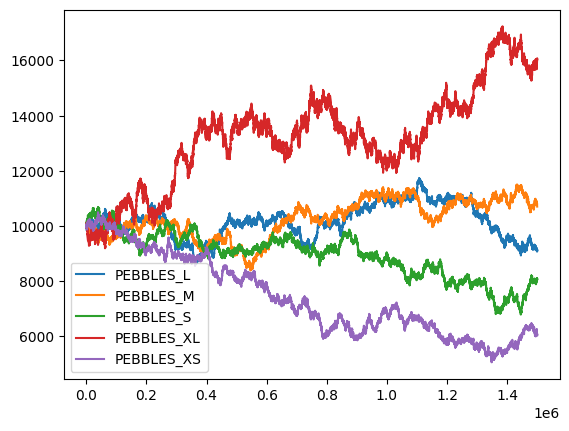

In [35]:
for p in pebbles:
    plt.plot(pebble_prices[pebble_prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [36]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

mids["XL_XS_avg"] = (mids["PEBBLES_XL"] + mids["PEBBLES_XS"]) / 2
mids["S_L_avg"]   = (mids["PEBBLES_S"]  + mids["PEBBLES_L"])  / 2
mids["basket_avg"]   = (mids["PEBBLES_S"]  + mids["PEBBLES_L"] + mids["PEBBLES_XL"] + mids["PEBBLES_XS"])  / 4
mids["avg"]   = (mids["PEBBLES_S"]  + mids["PEBBLES_L"] + mids["PEBBLES_XL"] + mids["PEBBLES_XS"] + mids["PEBBLES_M"])  / 5

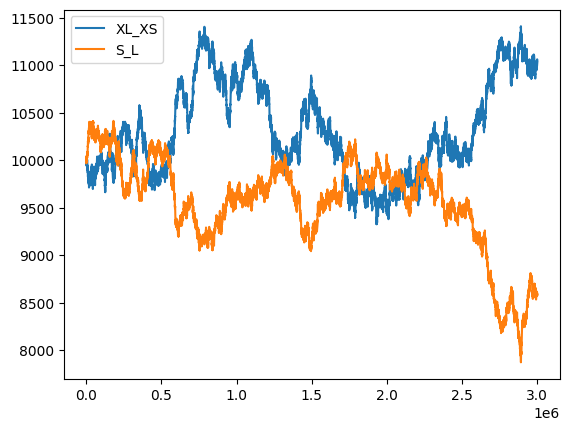

In [37]:
plt.plot(mids["XL_XS_avg"], label="XL_XS")
plt.plot(mids["S_L_avg"], label="S_L")
plt.legend()

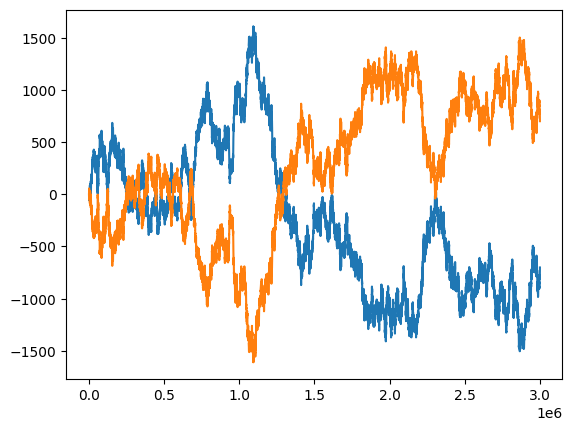

In [38]:
pebble_cols = [c for c in mids.columns if c.startswith("PEBBLES_")]
mids["PEBBLES_avg"] = mids[pebble_cols].mean(axis=1)

plt.plot(4 * (mids["basket_avg"] - 10_000))
plt.plot(mids["PEBBLES_M"] - 10_000)

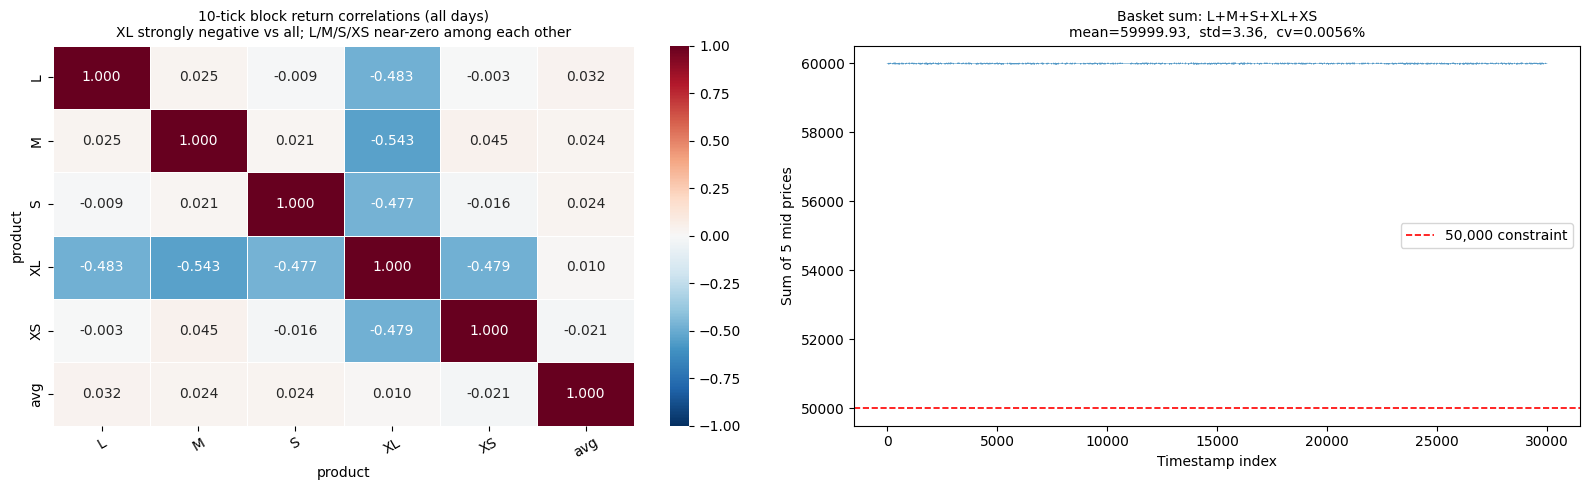

Basket sum ADF test:  stat=-122.6908,  p=0.000000  → STATIONARY (hard constraint)

Return correlations — XL vs each other product:
  XL vs L   : -0.4829
  XL vs M   : -0.5434
  XL vs S   : -0.4765
  XL vs XS  : -0.4794
  XL vs avg : +0.0095

  XL vs basket mean (L+M+S+XS avg): -0.9622

Key: XL is the balancing product — when the basket rises, XL must fall to maintain sum=50,000.


In [39]:

# ── 10-tick block returns and basket constraint ───────────────────────────────
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

BLOCK_TS   = 1000  # 10 ticks = 1000 timestamps
pebble_cols = [c for c in mids.columns if c.startswith("PEBBLES_")]
filled      = mids[pebble_cols].ffill()
blocked     = filled.groupby(filled.index // BLOCK_TS).last()
peb_returns = blocked.pct_change().dropna()

short_p = {c: c.replace("PEBBLES_", "") for c in pebble_cols}
corr_p  = peb_returns.corr().rename(columns=short_p, index=short_p)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: return correlation heatmap
sns.heatmap(corr_p, ax=axes[0], annot=True, fmt=".3f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar=True)
axes[0].set_title("10-tick block return correlations (all days)\n"
                  "XL strongly negative vs all; L/M/S/XS near-zero among each other", fontsize=10)
axes[0].tick_params(axis='x', rotation=30)

# Right: basket sum time series
basket_sum = mids[pebble_cols].sum(axis=1).dropna()
axes[1].plot(basket_sum.values, linewidth=0.4, color='#2980b9', alpha=0.8)
axes[1].axhline(50_000, color='red', linestyle='--', linewidth=1.2, label='50,000 constraint')
axes[1].set_title(
    f"Basket sum: L+M+S+XL+XS\n"
    f"mean={basket_sum.mean():.2f},  std={basket_sum.std():.2f},  "
    f"cv={basket_sum.std()/basket_sum.mean()*100:.4f}%", fontsize=10)
axes[1].set_xlabel("Timestamp index")
axes[1].set_ylabel("Sum of 5 mid prices")
axes[1].legend()

plt.tight_layout()
plt.show()

adf_stat, adf_p, *_ = adfuller(basket_sum.dropna())
print(f"Basket sum ADF test:  stat={adf_stat:.4f},  p={adf_p:.6f}  "
      f"→ {'STATIONARY (hard constraint)' if adf_p < 0.01 else 'non-stationary'}")

print(f"\nReturn correlations — XL vs each other product:")
for c in pebble_cols:
    if c != "PEBBLES_XL":
        r = peb_returns["PEBBLES_XL"].corr(peb_returns[c])
        print(f"  XL vs {short_p[c]:4s}: {r:+.4f}")

xl_vs_basket = peb_returns["PEBBLES_XL"].corr(
    peb_returns[[c for c in pebble_cols if c != "PEBBLES_XL"]].mean(axis=1))
print(f"\n  XL vs basket mean (L+M+S+XS avg): {xl_vs_basket:+.4f}")
print(f"\nKey: XL is the balancing product — when the basket rises, XL must fall to maintain sum=50,000.")


In [40]:

# ── Granger causality on 10-tick block returns ────────────────────────────────
from statsmodels.tsa.stattools import grangercausalitytests
from itertools import permutations
import warnings
warnings.filterwarnings("ignore")

MAXLAG = 10
sig_results = []

for a, b in permutations(pebble_cols, 2):
    data = peb_returns[[b, a]].dropna()
    res  = grangercausalitytests(data, maxlag=MAXLAG, verbose=False)
    ps   = {lag: res[lag][0]["ssr_ftest"][1] for lag in range(1, MAXLAG + 1)}
    best = min(ps, key=ps.get)
    if ps[best] < 0.05:
        sig_results.append((a, b, ps[best], best))

sig_results.sort(key=lambda x: x[2])

print("Significant Granger causality (p < 0.05):\n")
print(f"  {'Leader':8s}  →  {'Follower':8s}   p-value   lag (blocks / ticks)")
print("  " + "-" * 55)
for a, b, p, lag in sig_results:
    print(f"  {short_p[a]:8s}  →  {short_p[b]:8s}   {p:.4f}    lag={lag} / {lag*10} ticks")

print("""
Granger chain:
  M   → L   (lag 1 block /  10 ticks)   ← strongest (p≈0.008)
  S   → M   (lag 3 blocks / 30 ticks)
  L/S → XL  (lag 3 blocks / 30 ticks)
  XS  → S   (lag 1 block /  10 ticks)
  XL  → M   (lag 3 blocks / 30 ticks)   ← XL also feeds back

Note: Granger-based direction trades (buy S when XS moves up) lose to spread.
XL spread ≈ 16.6 units; typical 10-tick block signal ≈ 10 units → net negative.
Winning strategy: fade XL's early-day overshoot (1 trade/day, large move).
""")


Significant Granger causality (p < 0.05):

  Leader    →  Follower   p-value   lag (blocks / ticks)
  -------------------------------------------------------
  M         →  L          0.0084    lag=1 / 10 ticks
  S         →  M          0.0157    lag=3 / 30 ticks
  L         →  XL         0.0420    lag=3 / 30 ticks
  S         →  XL         0.0486    lag=3 / 30 ticks
  XS        →  S          0.0489    lag=1 / 10 ticks
  XL        →  M          0.0494    lag=3 / 30 ticks

Granger chain:
  M   → L   (lag 1 block /  10 ticks)   ← strongest (p≈0.008)
  S   → M   (lag 3 blocks / 30 ticks)
  L/S → XL  (lag 3 blocks / 30 ticks)
  XS  → S   (lag 1 block /  10 ticks)
  XL  → M   (lag 3 blocks / 30 ticks)   ← XL also feeds back

Note: Granger-based direction trades (buy S when XS moves up) lose to spread.
XL spread ≈ 16.6 units; typical 10-tick block signal ≈ 10 units → net negative.
Winning strategy: fade XL's early-day overshoot (1 trade/day, large move).



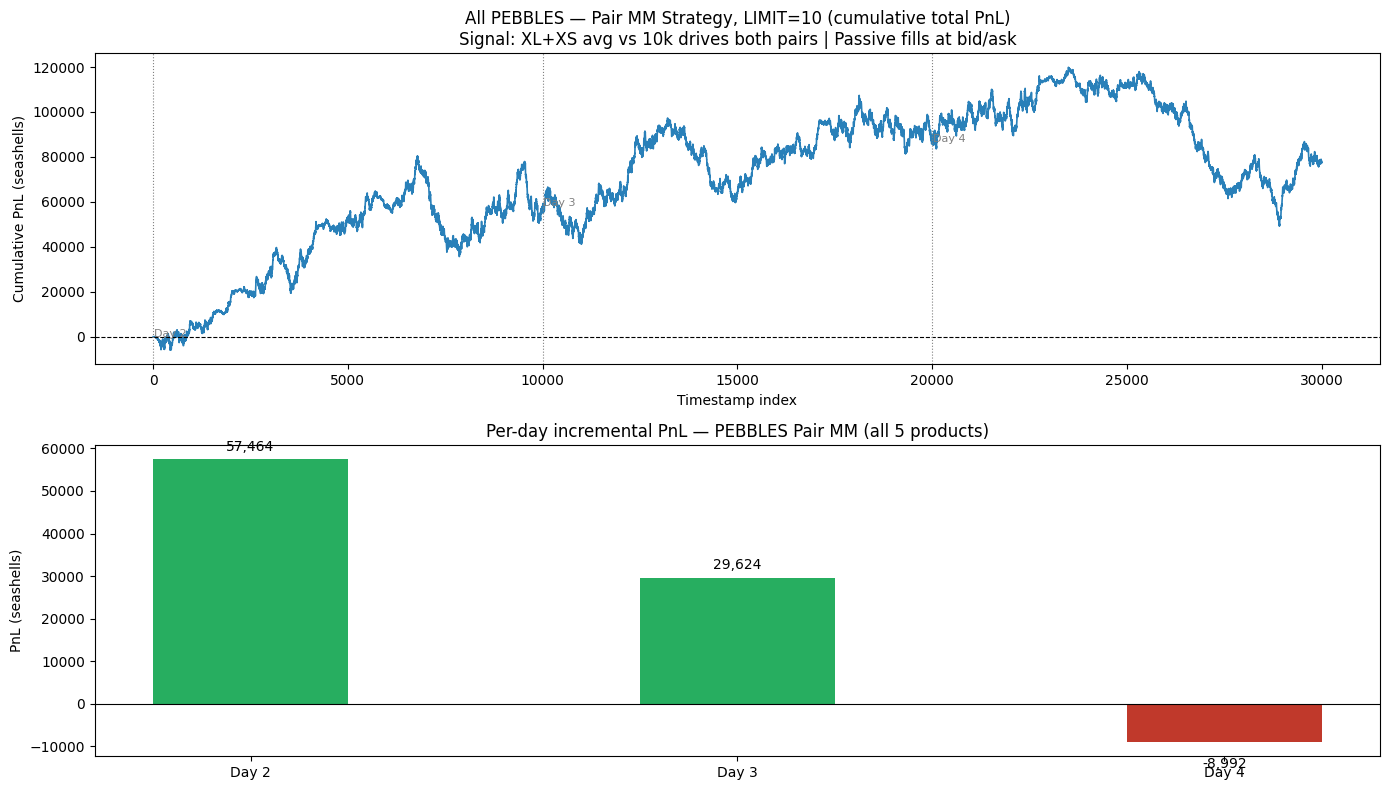

Per-product incremental PnL:
  product         Day2        Day3        Day4       Total
  L            +27,631      -3,674     -16,502      +7,455
  M             +7,094      +2,521      +3,570     +13,185
  S               -845     +14,395      +4,805     +18,355
  XL           +11,984      -3,527      +1,923     +10,380
  XS           +11,600     +19,909      -2,788     +28,721

Total PnL (all 5 products):
  Day 2: +57,464
  Day 3: +29,624
  Day 4: -8,992
  Grand Total: +78,096

Final positions: {'L': 10, 'M': -10, 'S': 10, 'XL': -10, 'XS': -10}


In [41]:

# ── Backtester + PebblesPairMMTrader ──────────────────────────────────────────
import sys
import json as _json
from collections import defaultdict

sys.path.insert(0, '..')
from datamodel import TradingState, Listing, OrderDepth, Trade, Order, Observation


class Backtester:
    def __init__(self, trader, listings, position_limit, fair_marks, market_data, trade_history):
        self.trader           = trader
        self.listings         = listings
        self.market_data      = market_data.copy()
        self.position_limit   = position_limit
        self.fair_marks       = fair_marks
        self.trade_history    = trade_history.sort_values(by=['timestamp', 'symbol'])
        self.observations     = [Observation({}, {}) for _ in range(len(market_data))]
        self.current_position = {p: 0 for p in listings}
        self.pnl_history      = []
        self.pnl              = {p: 0 for p in listings}
        self.cash             = {p: 0 for p in listings}

    def run(self):
        traderData    = ''
        ts_md         = self.market_data.groupby('timestamp')
        own_trades    = defaultdict(list)
        market_trades = defaultdict(list)

        trade_hist_dict = {}
        for ts, grp in self.trade_history.groupby('timestamp'):
            trade_hist_dict[ts] = [
                Trade(row['symbol'], int(row['price']), int(row['quantity']),
                      row['buyer'] if pd.notnull(row.get('buyer', '')) else '',
                      row['seller'] if pd.notnull(row.get('seller', '')) else '', ts)
                for _, row in grp.iterrows()
            ]

        for ts, grp in ts_md:
            od_trade = self._build_od(grp)
            od_pnl   = self._build_od(grp)
            state    = TradingState(traderData, ts, self.listings, od_trade,
                                    dict(own_trades), dict(market_trades),
                                    self.current_position, self.observations[0])
            orders, _, traderData = self.trader.run(state)

            products = grp['product'].tolist()

            # Snapshot bid/ask before our orders consume depth
            bids_snap = {}; asks_snap = {}
            for prod in products:
                od = od_trade.get(prod)
                if od and od.buy_orders:  bids_snap[prod] = max(od.buy_orders)
                if od and od.sell_orders: asks_snap[prod] = min(od.sell_orders)

            # Execute against depth; unfilled remainder = passive (resting limit order)
            passive_orders = defaultdict(list)
            for prod in products:
                for order in orders.get(prod, []):
                    done, _ = self._execute(ts, order, od_trade, self.current_position,
                                            self.cash, trade_hist_dict, '')
                    if done:
                        own_trades[prod].extend(done)
                    if order.quantity != 0:  # unfilled → passive resting
                        passive_orders[prod].append(order)

            # Passive fills: market trades crossing at our bid/ask quotes
            t_at_ts = trade_hist_dict.get(ts, [])
            for mt in t_at_ts:
                prod = mt.symbol
                if prod not in passive_orders:
                    continue
                bid = bids_snap.get(prod)
                ask = asks_snap.get(prod)
                mt_rem = mt.quantity
                for po in passive_orders[prod]:
                    if mt_rem <= 0:
                        break
                    if po.quantity > 0 and bid is not None and mt.price <= bid:
                        # Seller crossed at bid -> fills our passive buy
                        vol = min(po.quantity, mt_rem,
                                  int(self.position_limit[prod]) - self.current_position[prod])
                        if vol > 0:
                            own_trades[prod].append(Trade(prod, po.price, vol, 'SUBMISSION', '', ts))
                            self.current_position[prod] += vol
                            self.cash[prod] -= po.price * vol
                            po.quantity -= vol; mt_rem -= vol
                    elif po.quantity < 0 and ask is not None and mt.price >= ask:
                        # Buyer crossed at ask -> fills our passive sell
                        vol = min(abs(po.quantity), mt_rem,
                                  int(self.position_limit[prod]) + self.current_position[prod])
                        if vol > 0:
                            own_trades[prod].append(Trade(prod, po.price, vol, '', 'SUBMISSION', ts))
                            self.current_position[prod] -= vol
                            self.cash[prod] += po.price * vol
                            po.quantity += vol; mt_rem -= vol

            if t_at_ts:
                for t in t_at_ts: market_trades[t.symbol].append(t)
            else:
                for prod in products: market_trades[prod] = []

            for prod in products:
                self._mark(od_pnl, prod)
                self.pnl_history.append(self.pnl[prod])

        return self.pnl

    def _build_od(self, grp):
        od_map = {}
        for _, row in grp.iterrows():
            prod = row['product']; od = OrderDepth()
            for i in range(1, 4):
                bp, bv = row.get(f'bid_price_{i}'), row.get(f'bid_volume_{i}')
                ap, av = row.get(f'ask_price_{i}'), row.get(f'ask_volume_{i}')
                if pd.notna(bp) and pd.notna(bv) and str(bp) != '' and str(bv) != '':
                    od.buy_orders[int(float(bp))]  =  int(float(bv))
                if pd.notna(ap) and pd.notna(av) and str(ap) != '' and str(av) != '':
                    od.sell_orders[int(float(ap))] = -int(float(av))
            od_map[prod] = od
        return od_map

    def _mark(self, od_map, prod):
        od = od_map.get(prod)
        if od is None or not od.buy_orders or not od.sell_orders: return
        mid  = (max(od.buy_orders) + min(od.sell_orders)) / 2.0
        fair = self.fair_marks[prod](od) if prod in self.fair_marks else mid
        self.pnl[prod] = self.cash[prod] + fair * self.current_position[prod]

    def _execute(self, ts, order, od_map, pos, cash, hist, log):
        return (self._buy if order.quantity > 0 else self._sell)(ts, order, od_map, pos, cash, hist, log)

    def _buy(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.sell_orders):
            if price > order.price or order.quantity == 0: break
            vol = min(order.quantity, abs(od.sell_orders[price]),
                      int(self.position_limit[order.symbol]) - pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, 'SUBMISSION', '', ts))
                pos[order.symbol] += vol; cash[order.symbol] -= price * vol
                od.sell_orders[price] += vol; order.quantity -= vol
            if od.sell_orders.get(price) == 0: del od.sell_orders[price]
        return trades, log

    def _sell(self, ts, order, od_map, pos, cash, hist, log):
        trades, od = [], od_map[order.symbol]
        for price in sorted(od.buy_orders, reverse=True):
            if price < order.price or order.quantity == 0: break
            vol = min(abs(order.quantity), od.buy_orders[price],
                      int(self.position_limit[order.symbol]) + pos[order.symbol])
            if vol > 0:
                trades.append(Trade(order.symbol, price, vol, '', 'SUBMISSION', ts))
                pos[order.symbol] -= vol; cash[order.symbol] += price * vol
                od.buy_orders[price] -= vol; order.quantity += vol
            if od.buy_orders.get(price) == 0: del od.buy_orders[price]
        return trades, log


# ── PebblesPairMMTrader ─────────────────────────────────────────────────────────
class PebblesPairMMTrader:
    """
    Signal: XL+XS avg vs 10k drives BOTH pairs simultaneously.
    When XL+XS goes up, S+L goes down (basket constraint mirror).
      XL+XS avg >= 10k -> SHORT XL+XS, LONG S+L
      XL+XS avg <  10k -> LONG XL+XS, SHORT S+L
    M mirrors the basket (XL+S+L+XS) around 10k, traded solo.

    Execution: passive market-making at bid (buys) or ask (sells),
    4 units per quote (40% of LIMIT=10). Fills from market trade flow.
    """
    LIMIT     = 10
    THRESHOLD = 10_000.0
    MM_SIZE   = 4  # 40% of position limit per passive quote

    def run(self, state: TradingState):
        orders = {}
        syms = {'XL': 'PEBBLES_XL', 'XS': 'PEBBLES_XS',
                'S':  'PEBBLES_S',  'L':  'PEBBLES_L',  'M': 'PEBBLES_M'}
        bids = {}; asks = {}; mids = {}
        for k, sym in syms.items():
            od = state.order_depths.get(sym)
            if od and od.buy_orders and od.sell_orders:
                bids[k] = max(od.buy_orders)
                asks[k] = min(od.sell_orders)
                mids[k] = (bids[k] + asks[k]) / 2.0

        # Both pairs evaluated together via combined XL+XS signal (mirror enforced)
        if all(k in mids for k in ('XL', 'XS', 'S', 'L')):
            xl_xs_avg = (mids['XL'] + mids['XS']) / 2.0
            dir_xl_xs = -1 if xl_xs_avg >= self.THRESHOLD else 1
            dir_s_l   = -dir_xl_xs  # always opposite: S+L mirrors XL+XS

            for key, direction in [('XL', dir_xl_xs), ('XS', dir_xl_xs),
                                    ('S',  dir_s_l),   ('L',  dir_s_l)]:
                sym = syms[key]; od = state.order_depths.get(sym)
                if not od or key not in bids: continue
                pos    = state.position.get(sym, 0)
                target = direction * self.LIMIT
                needed = target - pos
                if needed == 0: continue
                qty = min(abs(needed), self.MM_SIZE)
                # Passive: post at bid (buy) or ask (sell) to earn spread, not pay it
                if needed > 0:
                    orders[sym] = [Order(sym, bids[key], qty)]
                else:
                    orders[sym] = [Order(sym, asks[key], -qty)]

        # M: solo mean-reversion around 10k, passive execution
        if 'M' in mids:
            sym = syms['M']; od = state.order_depths.get(sym)
            if od and 'M' in bids:
                direction = -1 if mids['M'] >= self.THRESHOLD else 1
                pos    = state.position.get(sym, 0)
                target = direction * self.LIMIT
                needed = target - pos
                if needed != 0:
                    qty = min(abs(needed), self.MM_SIZE)
                    if needed > 0:
                        orders[sym] = [Order(sym, bids['M'], qty)]
                    else:
                        orders[sym] = [Order(sym, asks['M'], -qty)]

        return orders, 0, state.traderData


# ── Load trade history ─────────────────────────────────────────────────────────
trade_rows, offset = [], 0
for day in DAYS:
    with open(f'./{BASE}/trades_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            row['timestamp'] = int(row['timestamp']) + offset
            trade_rows.append(row)
    offset += 1_000_000

all_trades = pd.DataFrame(trade_rows)
all_trades['timestamp'] = pd.to_numeric(all_trades['timestamp'])
all_trades['price']     = pd.to_numeric(all_trades['price'],    errors='coerce')
all_trades['quantity']  = pd.to_numeric(all_trades['quantity'], errors='coerce')
pebble_trades = all_trades[all_trades['symbol'].str.startswith('PEBBLES', na=False)].copy()
if 'buyer'  not in pebble_trades.columns: pebble_trades['buyer']  = ''
if 'seller' not in pebble_trades.columns: pebble_trades['seller'] = ''

# ── Run backtest ───────────────────────────────────────────────────────────────
PEBBLE_PRODUCTS = list(pebble_prices['product'].unique())
POS_LIMIT       = 10

listings  = {p: Listing(p, p, 'SEASHELLS') for p in PEBBLE_PRODUCTS}
pos_lim   = {p: POS_LIMIT for p in PEBBLE_PRODUCTS}

trader     = PebblesPairMMTrader()
backtester = Backtester(trader, listings, pos_lim, {}, pebble_prices, pebble_trades)
final_pnl  = backtester.run()

# ── Align PnL history to market data rows ─────────────────────────────────────
md_with_pnl = pebble_prices.copy().reset_index(drop=True)
md_with_pnl['pnl'] = backtester.pnl_history

DAY_BOUNDS = [(0, 1_000_000), (1_000_000, 2_000_000), (2_000_000, 3_000_000)]

pnl_by_prod = {}
for prod in PEBBLE_PRODUCTS:
    s = md_with_pnl[md_with_pnl['product'] == prod].set_index('timestamp')['pnl']
    pnl_by_prod[prod] = s

prod_day_pnl = {}; prev_cum = {prod: 0.0 for prod in PEBBLE_PRODUCTS}
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    for prod in PEBBLE_PRODUCTS:
        s = pnl_by_prod[prod]; mask = (s.index >= lo) & (s.index < hi)
        if mask.any():
            cum = s[mask].iloc[-1]
            prod_day_pnl.setdefault(prod, {})[f'Day {d}'] = cum - prev_cum[prod]
            prev_cum[prod] = cum

total_pnl_by_day = {f'Day {d}': sum(prod_day_pnl.get(prod, {}).get(f'Day {d}', 0)
                                    for prod in PEBBLE_PRODUCTS)
                    for d in range(2, 5)}
total_cum_pnl = md_with_pnl.groupby('timestamp')['pnl'].sum()

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

axes[0].plot(total_cum_pnl.values, color='#2980b9', linewidth=1.2)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
for d, (lo, hi) in enumerate(DAY_BOUNDS, 2):
    idx_arr = np.where(total_cum_pnl.index >= lo)[0]
    if len(idx_arr):
        axes[0].axvline(idx_arr[0], color='gray', linewidth=0.8, linestyle=':')
        axes[0].text(idx_arr[0] + 20, total_cum_pnl.values[idx_arr[0]], f'Day {d}', fontsize=8, color='gray')
axes[0].set_title('All PEBBLES — Pair MM Strategy, LIMIT=10 (cumulative total PnL)\n'
                  'Signal: XL+XS avg vs 10k drives both pairs | Passive fills at bid/ask')
axes[0].set_ylabel('Cumulative PnL (seashells)')
axes[0].set_xlabel('Timestamp index')

colors = ['#27ae60' if v >= 0 else '#c0392b' for v in total_pnl_by_day.values()]
axes[1].bar(total_pnl_by_day.keys(), total_pnl_by_day.values(), color=colors, width=0.4)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, (label, val) in enumerate(total_pnl_by_day.items()):
    axes[1].text(i, val + (2000 if val >= 0 else -6000), f'{val:,.0f}', ha='center', fontsize=10)
axes[1].set_title('Per-day incremental PnL — PEBBLES Pair MM (all 5 products)')
axes[1].set_ylabel('PnL (seashells)')

plt.tight_layout()
plt.show()

# ── Summary ────────────────────────────────────────────────────────────────────
short_name = lambda p: p.replace('PEBBLES_', '')
print('Per-product incremental PnL:')
print(f"  {'product':8s}  {'Day2':>10s}  {'Day3':>10s}  {'Day4':>10s}  {'Total':>10s}")
for prod in PEBBLE_PRODUCTS:
    d2  = prod_day_pnl.get(prod, {}).get('Day 2', 0)
    d3  = prod_day_pnl.get(prod, {}).get('Day 3', 0)
    d4  = prod_day_pnl.get(prod, {}).get('Day 4', 0)
    tot = d2 + d3 + d4
    print(f"  {short_name(prod):8s}  {d2:>+10,.0f}  {d3:>+10,.0f}  {d4:>+10,.0f}  {tot:>+10,.0f}")

print(f'\nTotal PnL (all 5 products):')
for label, val in total_pnl_by_day.items():
    print(f'  {label}: {val:>+,.0f}')
grand = sum(total_pnl_by_day.values())
print(f'  Grand Total: {grand:>+,.0f}')
print(f"\nFinal positions: { {short_name(k): v for k, v in backtester.current_position.items()} }")
